In [1]:
import pandas as pd

df = pd.read_csv("data/house_prices.csv")
print(df.shape)
df.head()

(187531, 21)


,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [2]:
df.info()
df.describe()
df.isna().mean().sort_values(ascending=False)

<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 non-null  str    
 15  Balcony            138596 non-null  str    
 16  Car Parking  

Plot Area            1.000000
Dimensions           1.000000
Society              0.584853
Super Area           0.574225
Car Parking          0.551146
overlooking          0.434254
Carpet Area          0.430185
facing               0.374514
Ownership            0.349366
Balcony              0.260944
Price (in rupees)    0.094198
Floor                0.037738
Description          0.016120
Furnishing           0.015448
Bathroom             0.004415
Status               0.003279
Transaction          0.000443
Amount(in rupees)    0.000000
Title                0.000000
Index                0.000000
location             0.000000
dtype: float64

In [3]:
def parse_amount(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 1e5
        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 1e7
        return float(x.replace(",", ""))
    except ValueError:
        return None

df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)
df = df.dropna(subset=["price_clean"])
df[["Amount(in rupees)", "price_clean"]].head()

,Amount(in rupees),price_clean
0,42 Lac,4200000.0
1,98 Lac,9800000.0
2,1.40 Cr,14000000.0
3,25 Lac,2500000.0
4,1.60 Cr,16000000.0


In [4]:
import re

def parse_area(x):
    if not isinstance(x, str):
        return None
    x = x.lower().strip()
    match = re.search(r'([\d\.]+)', x)
    if not match:
        return None
    val = float(match.group(1))
    if 'sqm' in x or 'sq.m' in x:
        return val * 10.7639
    elif 'sqyrd' in x or 'sq.yd' in x:
        return val * 9.0
    return val

df['carpet_sqft'] = df['Carpet Area'].apply(parse_area)
df['super_sqft'] = df['Super Area'].apply(parse_area)
df['area_sqft'] = df['carpet_sqft'].fillna(df['super_sqft'])
df = df.dropna(subset=['area_sqft'])
df[['Carpet Area', 'Super Area', 'area_sqft']].head()

,Carpet Area,Super Area,area_sqft
0,500 sqft,NaN,500.0
1,473 sqft,NaN,473.0
2,779 sqft,NaN,779.0
3,530 sqft,NaN,530.0
4,635 sqft,NaN,635.0


In [5]:
df['bhk'] = df['Title'].str.extract(r'(\d+)').astype(float)
df['bhk'] = df['bhk'].fillna(df['Description'].str.extract(r'(\d+)\s*bhk', flags=re.IGNORECASE)[0].astype(float))
df['bhk'] = df['bhk'].fillna(1)

df['bathroom_clean'] = pd.to_numeric(df['Bathroom'], errors='coerce').fillna(1)

df['floor_clean'] = df['Floor'].str.extract(r'(\d+)').astype(float).fillna(1)

df[['Title', 'bhk', 'bathroom_clean', 'floor_clean']].head()

,Title,bhk,bathroom_clean,floor_clean
0,1 BHK Ready to Occupy Flat for sale in Srushti...,1.0,1.0,10.0
1,2 BHK Ready to Occupy Flat for sale in Dosti V...,2.0,2.0,3.0
2,2 BHK Ready to Occupy Flat for sale in Sunrise...,2.0,2.0,10.0
3,1 BHK Ready to Occupy Flat for sale Kasheli,1.0,1.0,1.0
4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,2.0,2.0,20.0


C:\Users\dream\AppData\Local\Temp\ipykernel_22580\2438959620.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Furnishing', y=np.log1p(df['price_clean']), data=df, palette='Set2')


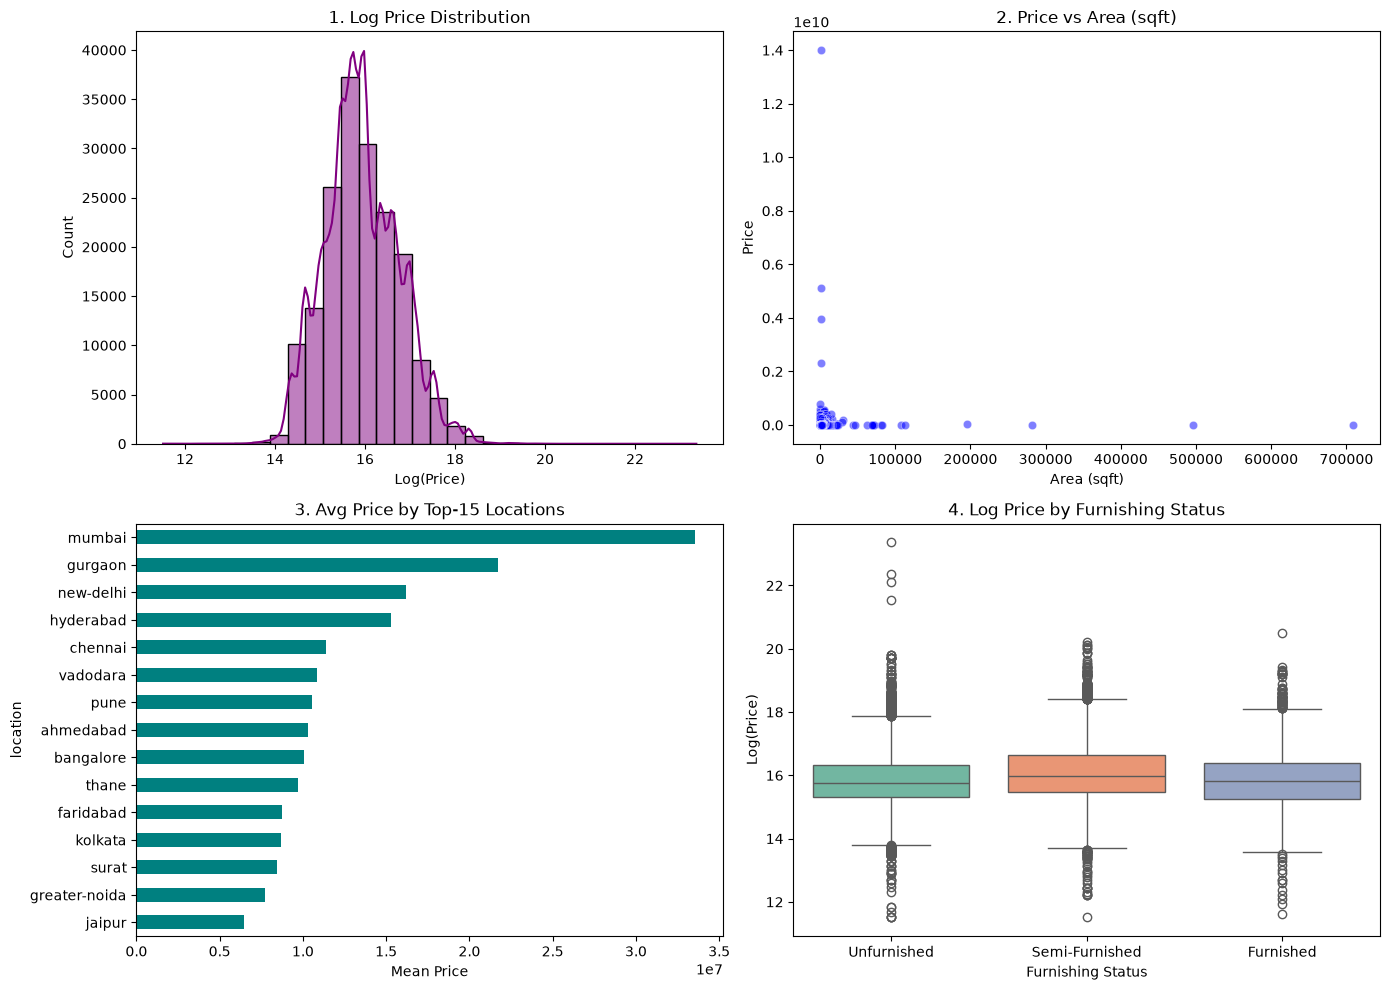

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
sns.histplot(np.log1p(df['price_clean']), bins=30, kde=True, color='purple')
plt.title('1. Log Price Distribution')
plt.xlabel('Log(Price)')

plt.subplot(2, 2, 2)
sns.scatterplot(x='area_sqft', y='price_clean', data=df, alpha=0.5, color='blue')
plt.title('2. Price vs Area (sqft)')
plt.xlabel('Area (sqft)')
plt.ylabel('Price')

plt.subplot(2, 2, 3)
top_locations = df['location'].value_counts().head(15).index
top_df = df[df['location'].isin(top_locations)]
top_df.groupby('location')['price_clean'].mean().sort_values().plot(kind='barh', color='teal')
plt.title('3. Avg Price by Top-15 Locations')
plt.xlabel('Mean Price')

plt.subplot(2, 2, 4)
sns.boxplot(x='Furnishing', y=np.log1p(df['price_clean']), data=df, palette='Set2')
plt.title('4. Log Price by Furnishing Status')
plt.xlabel('Furnishing Status')
plt.ylabel('Log(Price)')

plt.tight_layout()
plt.show()

In [10]:
df['price_per_sqft'] = df['price_clean'] / df['area_sqft']

top_cities = df['location'].value_counts().head(10).index
df['is_top_city'] = df['location'].isin(top_cities).astype(int)

df['furnishing_code'] = df['Furnishing'].map({'Unfurnished': 0, 'Semi-Furnished': 1, 'Furnished': 2}).fillna(0)

df[['price_per_sqft', 'is_top_city', 'furnishing_code']].head()

,price_per_sqft,is_top_city,furnishing_code
0,8400.000000,0,0.0
1,20718.816068,0,1.0
2,17971.758665,0,0.0
3,4716.981132,0,0.0
4,25196.850394,0,0.0


In [11]:
df['price_per_sqft'] = df['price_clean'] / df['area_sqft']
df = df[(df['price_per_sqft'] >= 1000) & (df['price_per_sqft'] <= 50000)]
df = df[(df['area_sqft'] >= 100) & (df['area_sqft'] <= 10000)]

df['furnishing_code'] = df['Furnishing'].map({'Unfurnished': 0, 'Semi-Furnished': 1, 'Furnished': 2}).fillna(0)
top_10_locs = df['location'].value_counts().head(10).index
df['is_top_location'] = df['location'].isin(top_10_locs).astype(int)

df[['price_clean', 'area_sqft', 'bhk', 'bathroom_clean', 'furnishing_code', 'is_top_location']].head()

,price_clean,area_sqft,bhk,bathroom_clean,furnishing_code,is_top_location
0,4200000.0,500.0,1.0,1.0,0.0,0
1,9800000.0,473.0,2.0,2.0,1.0,0
2,14000000.0,779.0,2.0,2.0,0.0,0
3,2500000.0,530.0,1.0,1.0,0.0,0
4,16000000.0,635.0,2.0,2.0,0.0,0


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

features = ['area_sqft', 'bhk', 'bathroom_clean', 'floor_clean', 'furnishing_code', 'is_top_location']
X = df[features]
y = np.log1p(df['price_clean'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"R2 Score: {r2:.4f}")

RMSE: 0.3090
R2 Score: 0.8547


In [13]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

features = ['area_sqft', 'bhk', 'bathroom_clean', 'floor_clean', 'furnishing_code', 'is_top_location']
X = df[features]
y = np.log1p(df['price_clean'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(n_estimators=30, n_jobs=-1, random_state=42))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print(f"Pipeline R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"Pipeline RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

Pipeline R2 Score: 0.8536
Pipeline RMSE: 0.3101


MAE:  0.1549
RMSE: 0.3101
R2:   0.8536


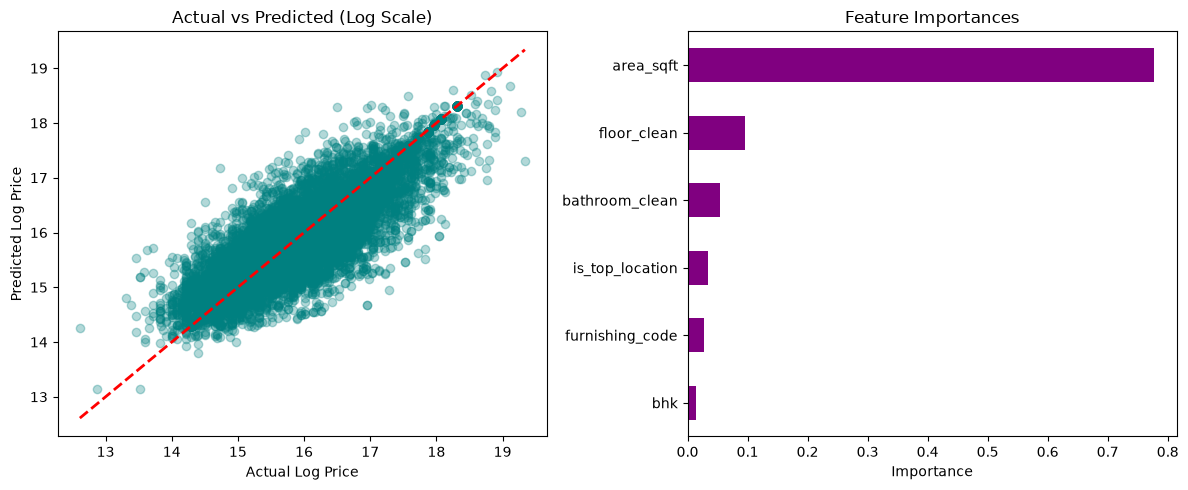

In [14]:
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import pandas as pd

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2:   {r2:.4f}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.3, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs Predicted (Log Scale)')
plt.xlabel('Actual Log Price')
plt.ylabel('Predicted Log Price')

model = pipeline.named_steps['model']
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True)

plt.subplot(1, 2, 2)
importances.plot(kind='barh', color='purple')
plt.title('Feature Importances')
plt.xlabel('Importance')

plt.tight_layout()
plt.show()

In [15]:
import joblib

joblib.dump(pipeline, 'house_price_model.pkl')
print("Model exported successfully as 'house_price_model.pkl'")

Model exported successfully as 'house_price_model.pkl'


In [16]:
loaded_pipeline = joblib.load('house_price_model.pkl')

sample_data = pd.DataFrame([{
    'area_sqft': 1200,
    'bhk': 2,
    'bathroom_clean': 2,
    'floor_clean': 3,
    'furnishing_code': 1,
    'is_top_location': 1
}])

log_pred = loaded_pipeline.predict(sample_data)[0]
actual_price_pred = np.expm1(log_pred)

print(f"Predicted Price: {actual_price_pred:.2f}")

Predicted Price: 5288190.09
